# Platform Pricing: Who Pays, Who Gets Paid

> Computational Analysis of Social Complexity
>
> Fall 2026, Spencer Lyon

**Prerequisites**

- L11.01
- L11.02
- Game theory (week 8)

**Outcomes**

- Formulate a platform's two-sided pricing problem
- Derive and solve first-order conditions numerically in Python
- Explain why optimal platform prices can be zero or negative on one side
- Distinguish price structure from price level and apply the distinction to real cases

**References**

- Required primary text: [Easley & Kleinberg, *Networks, Crowds, and Markets*, chapter 17](https://www.cs.cornell.edu/home/kleinber/networks-book/networks-book.pdf)
- Required: [Rochet & Tirole, *Two-Sided Markets: An Overview*](https://web.mit.edu/14.271/www/rochet_tirole.pdf)
- [Hagiu & Wright (2014)](https://www.hbs.edu/ris/Publication%20Files/15-037_cb5afe51-6150-4be9-ace2-39c6a8ace6d4.pdf)
- Optional extra reading: *Matchmakers* (Evans & Schmalensee 2016), chapter 11

## Ladies' Night

- A nightclub charges men $20 and women $0
- Unfair—or is the club solving an optimization problem?
- A person on either side values the club more when the other side shows up
- Charging everyone the same price may leave the dance floor empty
- Today we solve the platform's actual problem and derive this asymmetry

### The Pattern Is Everywhere

- Credit cards: cardholders receive rewards while merchants pay roughly 2–3%
- OpenTable: diners search and book for free while restaurants pay per seated diner
- Google search: users search for free while advertisers fund the system
- These are not three unrelated discounts
- They are choices about **who pays** so that both sides participate

### From Ignition to Pricing

- In L11.01 we separated **same-side network effects** from **cross-side network effects**
- In L11.02 the **chicken-and-egg problem** made it hard to reach **critical mass**
- Once participation passes a threshold, feedback can create **tipping**
- Pricing is one lever for getting the fragile side onto the platform
- First, however, we need a one-sided benchmark

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve

np.random.seed(6318)
plt.rcParams["lines.linewidth"] = 3
plt.rcParams["figure.figsize"] = (7.6, 4.4)
plt.rcParams["legend.loc"] = "best" 

## Build 1: A One-Sided Warm-Up

- Suppose a monopolist sells one product to one group of customers
- Demand falls linearly as price rises
- The firm trades off a larger margin against fewer sales
- There is no second group whose participation changes customer value

### Solve It by Hand

- Let demand be $D(p)=a-bp$ and marginal cost be $c$
- Profit is

$$\pi(p)=(p-c)(a-bp).$$

- Differentiate only after the economic tradeoff is clear:

$$\pi'(p)=a+bc-2bp=0.$$

- The interior monopoly price is

$$p^*=\frac{a+bc}{2b}=\frac{1}{2}\left(\frac{a}{b}+c\right).$$

- It sits halfway between marginal cost and the choke price $a/b$

In [2]:
def demand(p, a=10.0, b=1.0):
    return max(a - b * p, 0.0)


def monopoly_profit(p, a=10.0, b=1.0, c=2.0):
    return (p - c) * demand(p, a=a, b=b)


def monopoly_price(a=10.0, b=1.0, c=2.0):
    return (a + b * c) / (2 * b)


one_sided = dict(a=10.0, b=1.0, c=2.0)
p_mono = monopoly_price(**one_sided)
print("Analytic monopoly price:", round(p_mono, 2))
print("Demand at the optimum:", demand(p_mono, a=one_sided["a"], b=one_sided["b"]))

Analytic monopoly price: 6.0
Demand at the optimum: 4.0


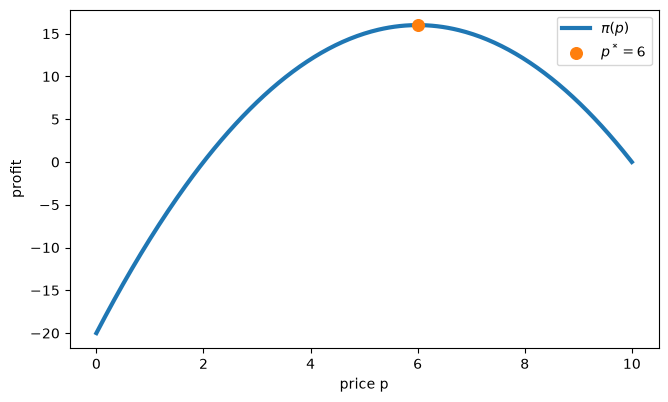

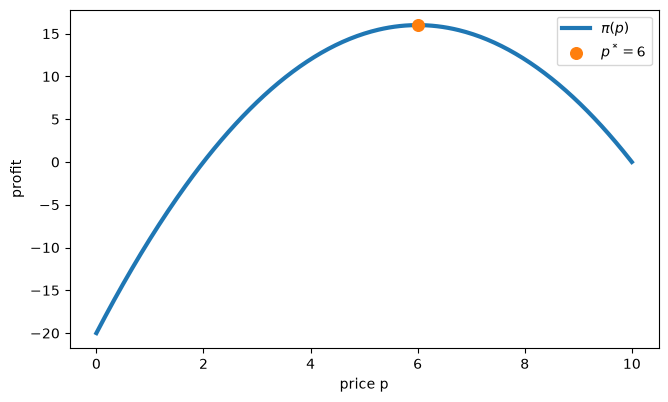

In [3]:
prices = np.linspace(0.0, one_sided["a"] / one_sided["b"], 301)
profits = [monopoly_profit(p, **one_sided) for p in prices]

fig, ax = plt.subplots()
ax.plot(prices, profits, label=r"$\pi(p)$")
ax.scatter([p_mono], [monopoly_profit(p_mono, **one_sided)], s=70, color="C1", label=r"$p^*=6$", zorder=3)
ax.set_xlabel("price p")
ax.set_ylabel("profit")
ax.legend()
fig

### Benchmark Result

- With $a=10$, $b=1$, and $c=2$, the curve peaks at $p^*=6$
- A standard one-sided monopolist with downward-sloping demand does not price below marginal cost at an interior optimum
- A subsidy loses money on each sale and creates no revenue anywhere else
- Keep that logic in mind—the platform result will break it

## Build 2: Two Sides Must Meet

- Now the platform serves buyers $B$ and sellers $S$
- It sets per-interaction prices $p_B$ and $p_S$
- One buyer without a seller creates no interaction
- One seller without a buyer creates no interaction
- This complementarity is the whole model

### A Simplified Rochet–Tirole Model

- Participation on each side responds to its own price:

$$D_B(p_B)=a_B-b_Bp_B, \qquad D_S(p_S)=a_S-b_Sp_S.$$

- Interactions require both sides, so volume is $D_BD_S$
- With cost $c$ per interaction, the margin is $p_B+p_S-c$
- Profit is

$$\pi(p_B,p_S)=(p_B+p_S-c)D_B(p_B)D_S(p_S).$$

- We restrict attention to prices with $D_B\geq 0$ and $D_S\geq 0$

### The Cross-Side Externality

- Raise $p_B$ and some buyers leave
- A one-sided firm counts the lost buyer sales
- A platform also counts the value destroyed for **every seller**
- The same logic runs from sellers back to buyers
- This is a **cross-side network effect** inside the profit function
- Question: should the two sides still pay the same price?

In [4]:
def D_B(p_B, pars):
    return pars["aB"] - pars["bB"] * p_B


def D_S(p_S, pars):
    return pars["aS"] - pars["bS"] * p_S


def platform_profit(p_B, p_S, pars):
    buyers = D_B(p_B, pars)
    sellers = D_S(p_S, pars)
    if buyers < 0 or sellers < 0:
        return -np.inf
    return (p_B + p_S - pars["c"]) * buyers * sellers


symmetric = dict(aB=10.0, bB=1.0, aS=10.0, bS=1.0, c=2.0)

## Build 3: Search the Price Surface

- Before taking derivatives, let the computer show us the landscape
- We evaluate profit on a grid of feasible prices
- The window includes subsidies and both choke prices
- Then we mark the best grid point

In [5]:
pB_grid = np.linspace(-2.0, symmetric["aB"] / symmetric["bB"], 241)
pS_grid = np.linspace(-2.0, symmetric["aS"] / symmetric["bS"], 241)
profit_grid = np.array([[platform_profit(pB, pS, symmetric) for pB in pB_grid] for pS in pS_grid])

grid_index = np.unravel_index(np.argmax(profit_grid), profit_grid.shape)
grid_solution = dict(pB=pB_grid[grid_index[1]], pS=pS_grid[grid_index[0]])
grid_profit = profit_grid[grid_index]
print("Best grid prices:", grid_solution)
print("Best grid profit:", round(grid_profit, 2))

Best grid prices: {'pB': np.float64(4.0), 'pS': np.float64(4.0)}
Best grid profit: 216.0


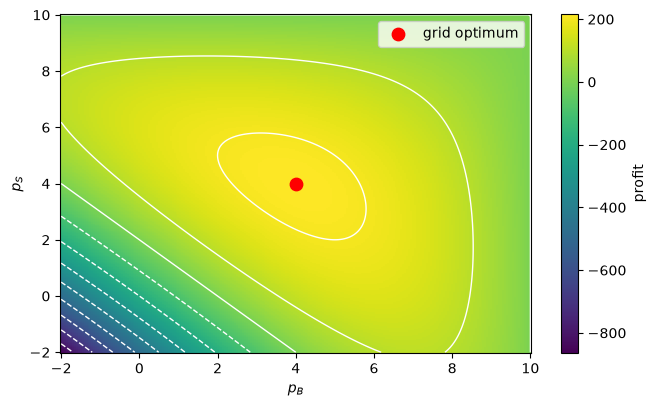

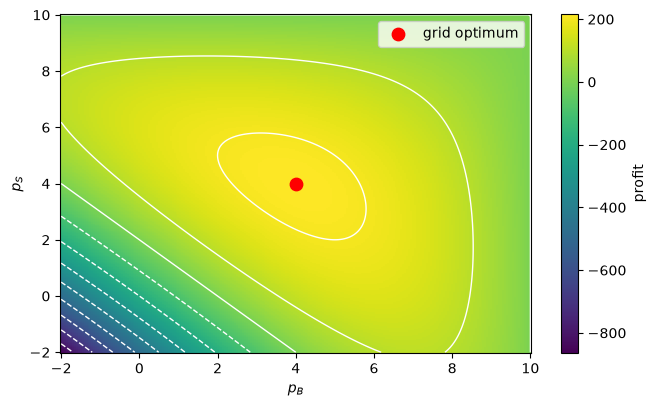

In [6]:
fig, ax = plt.subplots()
mesh = ax.pcolormesh(pB_grid, pS_grid, profit_grid, cmap="viridis", shading="auto")
fig.colorbar(mesh, ax=ax, label="profit")
ax.contour(pB_grid, pS_grid, profit_grid, levels=10, colors="white", linewidths=1)
ax.scatter([grid_solution["pB"]], [grid_solution["pS"]], color="red", s=80, label="grid optimum", zorder=3)
ax.set_xlabel(r"$p_B$")
ax.set_ylabel(r"$p_S$")
ax.legend()
fig

### What the Grid Says

- In the symmetric case, the best grid point is $(p_B,p_S)=(4,4)$
- Symmetric demand produces a symmetric **price structure**
- A grid is transparent and robust, but only approximates the optimum
- Can we recover the same answer from the first-order conditions?

## Derive the First-Order Conditions

- Write total per-interaction margin as $m=p_B+p_S-c$
- For positive participation, differentiating gives

$$\frac{\partial \pi}{\partial p_B}=D_S[D_B-b_Bm]=0,$$

$$\frac{\partial \pi}{\partial p_S}=D_B[D_S-b_Sm]=0.$$

- Substitute linear demand and divide by the slopes:

$$2p_B+p_S=\frac{a_B}{b_B}+c, \qquad p_B+2p_S=\frac{a_S}{b_S}+c.$$

- Solving yields

$$p_B^*=\frac{2}{3}\frac{a_B}{b_B}-\frac{1}{3}\frac{a_S}{b_S}+\frac{c}{3},$$

$$p_S^*=\frac{2}{3}\frac{a_S}{b_S}-\frac{1}{3}\frac{a_B}{b_B}+\frac{c}{3}.$$

In [7]:
def platform_focs(x, pars):
    p_B, p_S = x
    margin = p_B + p_S - pars["c"]
    buyers = D_B(p_B, pars)
    sellers = D_S(p_S, pars)
    return np.array([
        sellers * (buyers - pars["bB"] * margin),
        buyers * (sellers - pars["bS"] * margin),
    ])


def newton_system(f, x0, tolerance=1e-10, max_iterations=50):
    x = np.array(x0, dtype=float)
    for iteration in range(max_iterations):
        residual = f(x)
        if np.max(np.abs(residual)) < tolerance:
            return dict(root=x, iterations=iteration, residual=np.max(np.abs(residual)))
        jacobian = _jacobian(f, x)
        x = x - np.linalg.solve(jacobian, residual)
    raise RuntimeError("Newton's method did not converge")


def _jacobian(f, x, eps=1e-8):
    n = len(x)
    f0 = f(x)
    jac = np.zeros((len(f0), n))
    for j in range(n):
        step = np.zeros(n)
        step[j] = eps
        jac[:, j] = (f(x + step) - f0) / eps
    return jac

Note: `scipy` has no built-in autodiff for arbitrary Python functions, so `_jacobian` above uses a
forward-difference approximation; the Newton updates are still ours. `scipy.optimize.fsolve` (imported above)
offers an equivalent black-box alternative and is used later as a cross-check.

In [8]:
def closed_form_prices(pars):
    pB = (2 * pars["aB"] / pars["bB"] - pars["aS"] / pars["bS"] + pars["c"]) / 3
    pS = (2 * pars["aS"] / pars["bS"] - pars["aB"] / pars["bB"] + pars["c"]) / 3
    return dict(pB=pB, pS=pS)


newton_symmetric = newton_system(lambda x: platform_focs(x, symmetric), [2.0, 5.0])
analytic_symmetric = closed_form_prices(symmetric)
print("Newton prices:", np.round(newton_symmetric["root"], 6))
print("Closed-form prices:", analytic_symmetric)
print(
    "Distance from grid solution:",
    np.linalg.norm(newton_symmetric["root"] - [grid_solution["pB"], grid_solution["pS"]]),
)

Newton prices: [4. 4.]
Closed-form prices: {'pB': 4.0, 'pS': 4.0}
Distance from grid solution: 0.0


### Three Routes, One Answer

- The grid search, Newton solver, and closed-form algebra all give $(4,4)$
- The finite-difference Jacobian approximates the derivative, but the Newton updates are ours
- Agreement across methods is evidence that the code matches the model
- Symmetry is reassuring—but it hides the interesting economics

## Break the Symmetry

- Let buyers be much more price-sensitive than sellers
- Set $b_B=4$ and $b_S=0.5$, with both intercepts at 10 and cost at 2
- Before computing: which side should the platform protect?
- Losing one buyer also reduces the value delivered to sellers

In [9]:
asymmetric = dict(aB=10.0, bB=4.0, aS=10.0, bS=0.5, c=2.0)
newton_asymmetric = newton_system(lambda x: platform_focs(x, asymmetric), [-4.0, 13.0])
analytic_asymmetric = closed_form_prices(asymmetric)
pB_asym, pS_asym = newton_asymmetric["root"]

print("Buyer price:", round(pB_asym, 2))
print("Seller price:", round(pS_asym, 2))
print("Total price:", round(pB_asym + pS_asym, 2))
print("Per-interaction margin:", round(pB_asym + pS_asym - asymmetric["c"], 2))
print("Closed-form check:", analytic_asymmetric)

Buyer price: -4.33
Seller price: 13.17
Total price: 8.83
Per-interaction margin: 6.83
Closed-form check: {'pB': -4.333333333333333, 'pS': 13.166666666666666}


## Reveal 1: Subsidize the Sensitive Side

- The optimal buyer price is about **−4.33**
- The optimal seller price is about **13.17**
- The platform pays buyers to participate and charges sellers for access to them
- Yet the total price is about 8.83 and the per-interaction margin is about 6.83
- Ladies' Night, cashback rewards, and free restaurant reservations fall out of the same first-order conditions
- A negative price is not irrational when it creates profitable activity on the other side

### Price Structure vs Price Level

- The **price level** is the total charge per interaction: $p_B+p_S$
- The **price structure** is how that total is divided between the two sides
- Holding $p_B+p_S$ fixed but changing the split changes participation and volume
- That would be impossible in a genuinely one-sided market
- This sensitivity to price structure is Rochet and Tirole's key definition of two-sidedness

## Reveal 2: Comparative Statics

- One asymmetric example could be a coincidence
- Sweep buyer price sensitivity $b_B$ while holding the seller side fixed
- Trace both optimal prices and find the zero-price crossover
- Prediction: as buyers become easier to lose, buyers pay less and sellers pay more

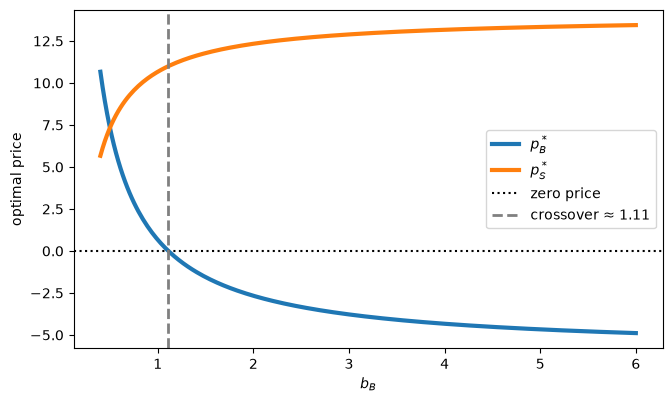

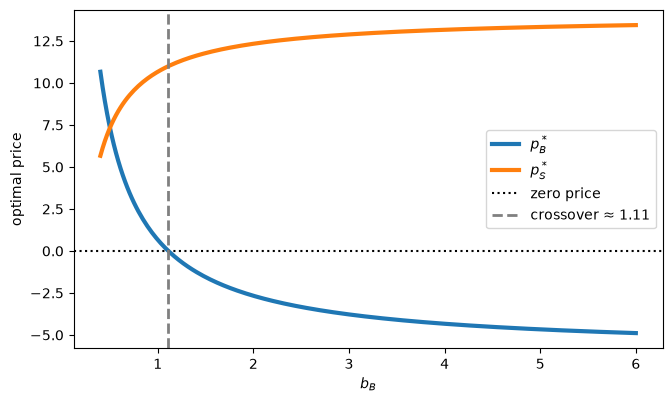

In [10]:
buyer_slopes = np.linspace(0.4, 6.0, 240)
sweep_parameters = [dict(asymmetric, bB=b) for b in buyer_slopes]
sweep_prices = [closed_form_prices(pars) for pars in sweep_parameters]
buyer_prices = np.array([p["pB"] for p in sweep_prices])
seller_prices = np.array([p["pS"] for p in sweep_prices])
zero_crossover = 2 * asymmetric["aB"] / (asymmetric["aS"] / asymmetric["bS"] - asymmetric["c"])

fig, ax = plt.subplots()
ax.plot(buyer_slopes, buyer_prices, label=r"$p_B^*$")
ax.plot(buyer_slopes, seller_prices, label=r"$p_S^*$")
ax.axhline(0.0, color="black", linestyle=":", linewidth=1.5, label="zero price")
ax.axvline(zero_crossover, color="gray", linestyle="--", linewidth=2,
           label=f"crossover ≈ {zero_crossover:.2f}")
ax.set_xlabel(r"$b_B$")
ax.set_ylabel("optimal price")
ax.legend()
fig

### Reading the Sweep

- The buyer price crosses zero at $b_B\approx 1.11$ for these parameters
- Beyond that point, greater buyer sensitivity produces a larger buyer subsidy
- The seller price rises because sellers benefit from the participation that subsidy creates
- **A one-sided monopolist would NEVER price below cost; a platform does it routinely and rationally**
- The qualification matters: the platform earns revenue from the cross-side response

### Pricing Can Help a Platform Ignite

- Subsidizing one side can help solve the **chicken-and-egg problem**
- Reaching **critical mass** strengthens cross-side participation and may trigger **tipping**
- Same-side congestion or rivalry can push in the opposite direction
- Our static linear model compresses those dynamics into demand curves
- The lesson is not "always subsidize buyers"; it is "price the network effect, not just the transaction" 

## Platforms in Court

- **Ohio v. American Express** treated credit-card transactions as a two-sided platform market
  - Evaluating merchant fees alone can miss cardholder rewards and changes in transaction volume
- **Epic Games v. Apple** put platform market definition and rules between users and developers at center stage
  - A developer commission cannot be interpreted without asking how users and developers respond together
- Courts increasingly require two-sided analysis when the relevant market links both groups
- Two-sided analysis does not mean every platform practice is efficient or lawful

### Multihoming and the Competitive Bottleneck

- **Multihoming** means participating on more than one platform
- Armstrong's competitive-bottleneck insight in one line:
  - Platforms court the side that single-homes and tax the side that multihomes
- Winning a single-homing participant can give access to that participant across competing platforms
- This adds competitive strategy to the cross-side logic in our monopoly model

### Exercise 1: Platform or Tariff?

- Consider Costco membership, Amazon Prime, and a farmers-market stall fee
- Is each example two-sided pricing or a plain two-part tariff?
- Identify the sides and the cross-side interaction, if any
- Use the test: would changing the **price structure** while holding the **price level** fixed change volume?
- Be ready to defend why a label such as "membership" or "fee" is not enough

### Exercise 2: More Sellers

- Return to the asymmetric parameterization
- Double the seller intercept from $a_S=10$ to $a_S=20$
- Re-solve for $p_B^*$ and $p_S^*$
- Which price rises? Which falls?
- Explain the result using the value of attracting the opposite side—not algebra alone

In [11]:
more_sellers = dict(asymmetric, aS=20.0)

# TODO: compute the new optimum with closed_form_prices or newton_system
# TODO: compare both prices with analytic_asymmetric
# TODO: explain why the changes have opposite signs

### Exercise 3: Charge for Membership Instead

- Our model charges each side per interaction
- Consider membership fees $F_B$ and $F_S$, each paid once
- With per-interaction cost $c$, profit becomes

$$\pi_M(F_B,F_S)=F_BD_B(F_B)+F_SD_S(F_S)-cD_B(F_B)D_S(F_S).$$

- Find the best membership fees on the grid
- Compare fees, participation, interaction volume, and profit with the usage-fee optimum
- Why are dollar values not directly interchangeable across the two models?

In [12]:
def membership_profit(F_B, F_S, pars):
    buyers = D_B(F_B, pars)
    sellers = D_S(F_S, pars)
    if buyers < 0 or sellers < 0:
        return -np.inf
    return F_B * buyers + F_S * sellers - pars["c"] * buyers * sellers


membership_B_grid = np.linspace(-5.0, asymmetric["aB"] / asymmetric["bB"], 301)
membership_S_grid = np.linspace(-5.0, asymmetric["aS"] / asymmetric["bS"], 301)

# TODO: evaluate membership_profit over both grids
# TODO: locate the maximizing pair of membership fees
# TODO: compare participation, volume, and profit across pricing models

### Exercise 4: Design a Compute Marketplace

- You run a GPU-compute marketplace matching AI startups to datacenter owners
- This calls back to our AI agents unit: startups deploy agents but need scarce compute
- Which side would you subsidize at launch, and why?
- Discuss price sensitivity, cross-side value, the chicken-and-egg problem, and multihoming
- What evidence would make you reverse the subsidy?
- Design one non-price incentive that could help reach critical mass

## Takeaways

- A platform chooses a vector of prices, not one price
- Cross-side network effects make participation on each side affect the value of the other
- The price-sensitive side may optimally pay zero or receive a subsidy
- Price structure can change volume even when the total price level does not
- Grid search, hand-derived first-order conditions, and Newton's method tell the same story
- As with Braess' paradox, familiar pieces can produce a surprising system-level result

## Next Time: Markets Without Prices

- Prices are one way to clear a market—but some markets refuse prices entirely
- Kidneys. Medical residencies. School seats.
- These markets **match** instead of price
- We will define a **stable matching** and ask whether any **blocking pair** can upset it
- Then we will build the deferred-acceptance algorithm that helped win a Nobel